<h1> SVM (Support Vector Machine)

SVM is a supervised learning algorithm primarily used for:

- Classification
- Regression (SVR)

The core idea:

Finding the optimal line or hyperplane that separates the classes while maximizing the distance to the nearest data points.

If we remove points far from the margin, the boundary does not change.

However, if the support vectors (points close to the margin) are removed, the boundary changes.

### Maximum Margin Principle

SVM solves an optimization problem:
Objective:

Maximize the margin

Formula:

$\max \frac{2}{||w||}$

Equivalent to:

$\min \frac{1}{2}||w||^2$

Subject to:

$y_i(w^Tx_i+b)\geq1$

Hard Margin SVM

Ideally, all points should be correctly classified.
However, the problem is that real-world data usually contains noise.

Soft Margin SVM

To address this issue:
We allow for some error.
Parameter:

$C$

Controls:

Small C => Larger margin: More tolerance / Simpler model.

Large C => Less error: Less tolerance / But higher risk of overfitting.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.svm import SVC


<h3> Step 1: Making a Simple Dataset

In [6]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

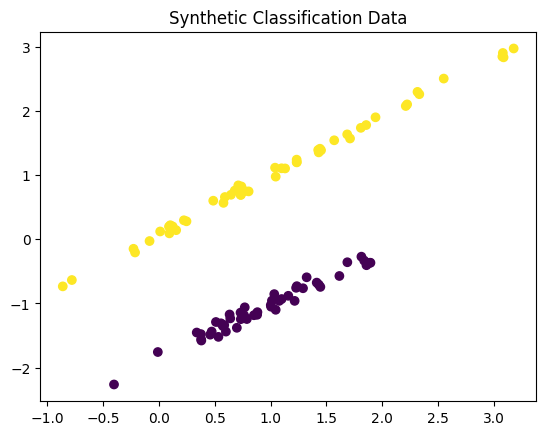

In [7]:
plt.scatter(
    X[:,0],
    X[:,1],
    c=y
)

plt.title(
    "Synthetic Classification Data"
)

plt.show()

<h3> Step 2: Linear SVM Implementation with Scikit-Learn

In [8]:
svm = SVC(
    kernel="linear",
    C=1
)

In [9]:
svm.fit(
    X,
    y
)

SVC(C=1, kernel='linear')

In [10]:
print(
    svm.support_vectors_
)

[[ 0.63356167 -1.17278867]
 [ 0.76916909 -1.0609667 ]
 [ 0.15559223  0.14096222]
 [-0.21198653 -0.20665158]
 [-0.85852241 -0.73473514]]


In [11]:
print(
    len(
        svm.support_vectors_
    )
)

5


This means the model used only 5 samples to determine the decision boundary.

<h3> Step 3: Decision Boundary Visualization

This part is very important because it is used in most classification algorithms to plot the decision boundary. The SVM model itself does not require this grid; it is solely for visualization purposes.

In [12]:
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1


xx, yy = np.meshgrid(
    np.linspace(x_min,x_max,200),
    np.linspace(y_min,y_max,200)
)

In [13]:
Z = svm.predict(
    np.c_[
        xx.ravel(),
        yy.ravel()
    ]
)

Z = Z.reshape(
    xx.shape
)

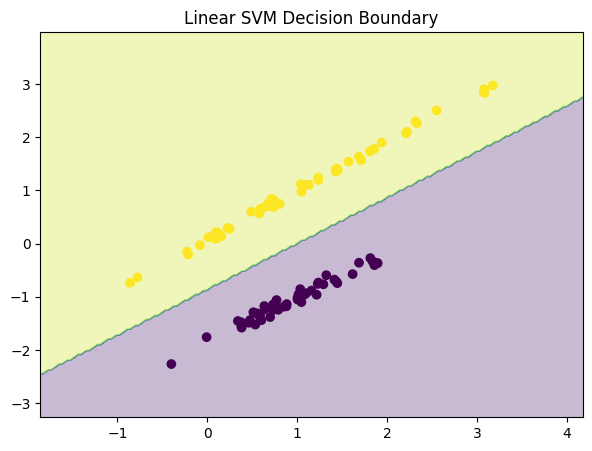

In [14]:
plt.figure(
    figsize=(7,5)
)

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y
)

plt.scatter(
    svm.support_vectors_[:,0],
    svm.support_vectors_[:,1],
    s=120,
    facecolors="none"
)

plt.title(
    "Linear SVM Decision Boundary"
)

plt.show()

SVM does not merely seek a separating line; rather, it looks for the line that maximizes the distance from both classes.

Actual data

(X, y)
| 
|
SVM.fit()
| 
↓

Learned model


-----------------

For plotting:

Create a grid over the data space

Generate a 200×200 grid of points

| 
↓

Feed each point into the SVM

| 
↓

Get the predicted class

| 
↓

Color-code the points

| 
↓

Decision Boundary

<h3> Step 4: Investigation of the C-effect

In [15]:
Cs = [
    0.01,
    1,
    100
]

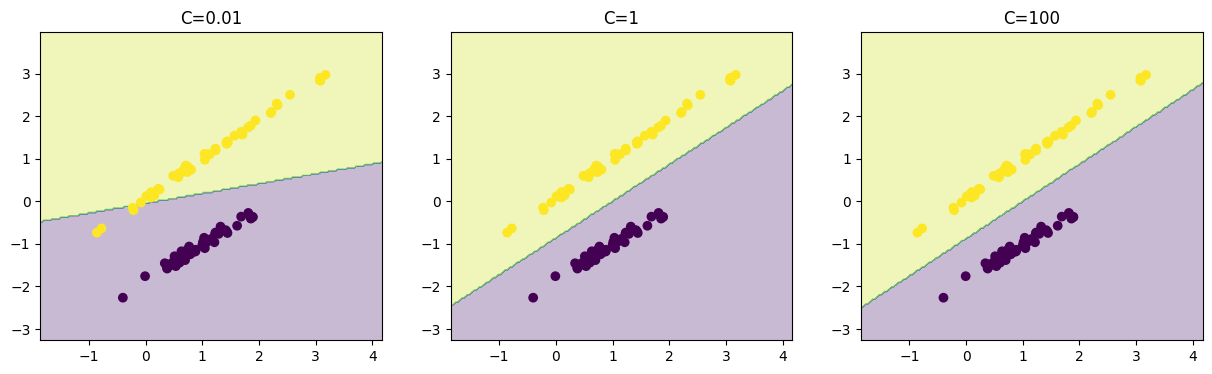

In [16]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,4)
)

for ax, C in zip(
    axes,
    Cs
):

    model = SVC(
        kernel="linear",
        C=C
    )

    model.fit(
        X,
        y
    )

    Z = model.predict(
        np.c_[
            xx.ravel(),
            yy.ravel()
        ]
    ).reshape(
        xx.shape
    )

    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )

    ax.scatter(
        X[:,0],
        X[:,1],
        c=y
    )

    ax.scatter(
        model.support_vectors_[:,0],
        model.support_vectors_[:,1],
        s=100,
        facecolors="none"
    )

    ax.set_title(
        f"C={C}"
    )

plt.show()

To plot the margin, we must use `decision_function` instead of `predict`.
This is because:
`svm.predict()`


returns only the class:
0 or 1

whereas:
`svm.decision_function()`


returns the distance of each point from the hyperplane.

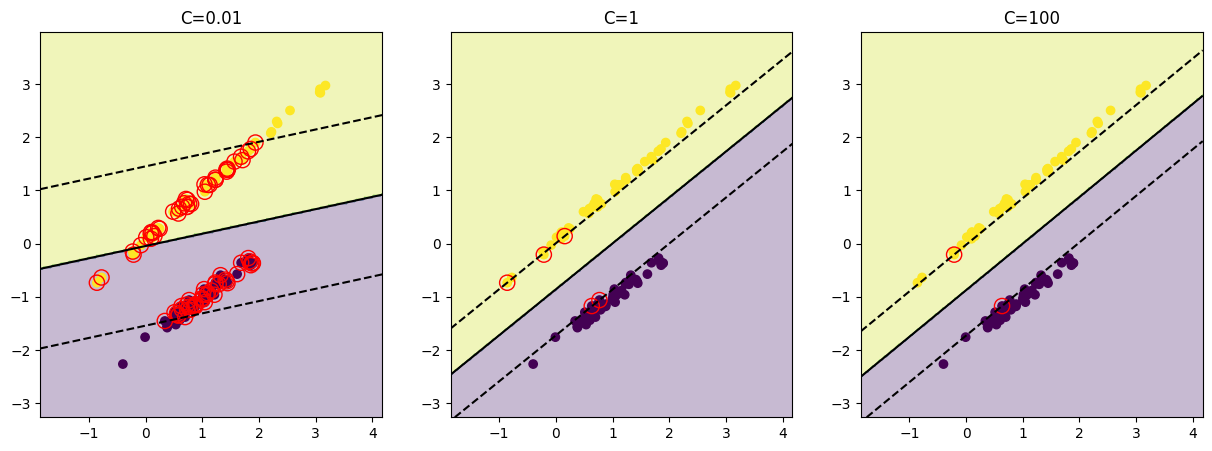

In [20]:
Cs = [
    0.01,
    1,
    100
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5)
)


for ax, C in zip(
    axes,
    Cs
):

    svm = SVC(
        kernel="linear",
        C=C
    )

    svm.fit(
        X,
        y
    )


    decision_values = svm.decision_function(
        np.c_[
            xx.ravel(),
            yy.ravel()
        ]
    )

    decision_values = decision_values.reshape(
        xx.shape
    )


    Z = svm.predict(
        np.c_[
            xx.ravel(),
            yy.ravel()
        ]
    )

    Z = Z.reshape(
        xx.shape
    )


    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )


    ax.contour(
        xx,
        yy,
        decision_values,
        levels=[
            -1,
            0,
            1
        ],
        colors="black",
        linestyles=[
            "--",
            "-",
            "--"
        ]
    )


    ax.scatter(
        X[:,0],
        X[:,1],
        c=y
    )


    ax.scatter(
        svm.support_vectors_[:,0],
        svm.support_vectors_[:,1],
        s=120,
        facecolors="none",
        edgecolors="red"
    )


    ax.set_title(
        f"C={C}"
    )


plt.show()